# Notebook 5: From-Scratch vs Frozen CLIP + Probe (Self-Contained)

## Goal (like your friend's method: train both in one place and compare)
This notebook is **independent** of Notebook 4. We do everything here:

1. **Approach A — Frozen CLIP + probe:** Load pre-trained CLIP (frozen), get embeddings for the same composite images, train a small MLP probe on them.

2. **Approach B — From-scratch CLIP-style:** Build a small vision encoder + class embeddings (CLIP-style structure), **train it from scratch** on the same composite data (no pre-trained weights).

Same data and train/val/test split for both. At the end we compare: **Frozen CLIP + probe: X%  |  From-scratch: Y%** — all in one notebook.

## 1. Setup and Imports

In [10]:
import random
from pathlib import Path
from typing import Tuple, List, Optional

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
from torchvision import transforms
from pycocotools.coco import COCO
from transformers import CLIPModel, CLIPProcessor

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("mps" if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

/Users/chenshengrui/Documents/GitHub/VLM-reasoning/.venv-vlm/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: mps


## 2. Configuration

In [11]:
CONFIG = {
    "coco_root": "data/coco",
    "coco_ann_file": "data/coco/annotations/instances_val2017.json",
    "coco_image_subdir": "val2017",
    "max_pairs": 1500,
    "train_ratio": 0.8,
    "val_ratio": 0.15,
    "img_size": 224,
    "embed_dim": 256,
    "batch_size": 32,
    "epochs": 40,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "early_stop_patience": 10,
    "results_dir": "results/scratch_clip_style",
    "clip_model": "openai/clip-vit-base-patch32",
    "probe_epochs": 50,
    "probe_lr": 5e-4,
    "probe_hidden": 128,
    "probe_dropout": 0.35,
    "probe_patience": 15,
}

## 3. Helpers: COCO + composite (same logic as Notebook 4)

In [12]:
def bbox_union(coco, img_id: int) -> Optional[Tuple[int,int,int,int]]:
    anns = coco.loadAnns(coco.getAnnIds(imgIds=[img_id]))
    if not anns:
        return None
    boxes = []
    for a in anns:
        x, y, w, h = a["bbox"]
        boxes.append((int(x), int(y), int(x+w), int(y+h)))
    return (min(b[0] for b in boxes), min(b[1] for b in boxes), max(b[2] for b in boxes), max(b[3] for b in boxes))

def composite_contradictory(img_a: Image.Image, img_b: Image.Image, bbox_a: tuple, bbox_b: tuple):
    wa, ha = img_a.size
    wb, hb = img_b.size
    x1a, y1a, x2a, y2a = bbox_a
    x1b, y1b, x2b, y2b = bbox_b
    fg_a = img_a.crop(bbox_a)
    fg_b = img_b.crop(bbox_b)
    bg_b = img_b.resize((wa, ha), Image.Resampling.LANCZOS)
    comp1 = bg_b.copy()
    comp1.paste(fg_a.resize((x2a-x1a, y2a-y1a), Image.Resampling.LANCZOS), (x1a, y1a))
    bg_a = img_a.resize((wb, hb), Image.Resampling.LANCZOS)
    comp2 = bg_a.copy()
    comp2.paste(fg_b.resize((x2b-x1b, y2b-y1b), Image.Resampling.LANCZOS), (x1b, y1b))
    return comp1, comp2

## 4. Dataset: composite images + labels (by pair index)

In [13]:
class CompositeDataset(Dataset):
    def __init__(self, pair_ids: List[Tuple[int,int]], coco: COCO, img_dir: Path, transform, label_mask: np.ndarray):
        self.pair_ids = pair_ids
        self.coco = coco
        self.img_dir = img_dir
        self.transform = transform
        self.label_mask = label_mask  # which pairs to include (train/val/test)
        self.samples = []  # (pair_idx, comp_idx 0 or 1) -> label 0 or 1
        for i, (id_a, id_b) in enumerate(pair_ids):
            if not label_mask[i]:
                continue
            self.samples.append((i, 0, 0))  # comp1, label A=0
            self.samples.append((i, 1, 1))  # comp2, label B=1

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        pair_idx, comp_idx, label = self.samples[idx]
        id_a, id_b = self.pair_ids[pair_idx]
        info_a = self.coco.loadImgs([id_a])[0]
        info_b = self.coco.loadImgs([id_b])[0]
        path_a = self.img_dir / info_a["file_name"]
        path_b = self.img_dir / info_b["file_name"]
        img_a = Image.open(path_a).convert("RGB")
        img_b = Image.open(path_b).convert("RGB")
        bbox_a = bbox_union(self.coco, id_a)
        bbox_b = bbox_union(self.coco, id_b)
        if not bbox_a or not bbox_b:
            return torch.zeros(3, 224, 224), 0  # fallback
        comp1, comp2 = composite_contradictory(img_a, img_b, bbox_a, bbox_b)
        comp = comp1 if comp_idx == 0 else comp2
        x = self.transform(comp)
        return x, label

## 5. Build pairs and train/val/test split (same as Notebook 4)

In [14]:
coco = COCO(CONFIG["coco_ann_file"])
img_dir = Path(CONFIG["coco_root"]) / CONFIG["coco_image_subdir"]
all_img_ids = [iid for iid in coco.getImgIds() if coco.getAnnIds(imgIds=[iid])]
random.shuffle(all_img_ids)
n_pairs = min(CONFIG["max_pairs"], len(all_img_ids) // 2)
pair_ids = [(all_img_ids[2*i], all_img_ids[2*i+1]) for i in range(n_pairs)]

train_ratio = CONFIG["train_ratio"]
val_ratio = CONFIG.get("val_ratio", 0.15)
n_test_min = max(10, n_pairs // 5)
n_train_pairs = max(1, min(int(n_pairs * train_ratio), n_pairs - n_test_min))
train_val_list = pair_ids[:n_train_pairs]
test_pairs_set = set(pair_ids[n_train_pairs:])
n_val = max(1, int(len(train_val_list) * val_ratio))
train_pairs_set = set(train_val_list[n_val:])
val_pairs_set = set(train_val_list[:n_val])

train_mask = np.array([tuple(p) in train_pairs_set for p in pair_ids])
val_mask = np.array([tuple(p) in val_pairs_set for p in pair_ids])
test_mask = np.array([tuple(p) in test_pairs_set for p in pair_ids])

print(f"Pairs: train {train_mask.sum()}, val {val_mask.sum()}, test {test_mask.sum()}")
print(f"Samples: train {2*train_mask.sum()}, val {2*val_mask.sum()}, test {2*test_mask.sum()}")

loading annotations into memory...
Done (t=0.30s)
creating index...
index created!
Pairs: train 1020, val 180, test 300
Samples: train 2040, val 360, test 600


## 5b. Frozen CLIP + probe (all in this notebook)

Load pre-trained CLIP, get embeddings for the same composite images, train a small probe. No dependency on Notebook 4.

In [15]:
clip_processor = CLIPProcessor.from_pretrained(CONFIG["clip_model"])
clip_model = CLIPModel.from_pretrained(CONFIG["clip_model"]).to(device).eval()
for p in clip_model.parameters():
    p.requires_grad = False
clip_embed_dim = clip_model.config.projection_dim

def get_embeddings_and_labels(id_a: int, id_b: int):
    info_a = coco.loadImgs([id_a])[0]
    info_b = coco.loadImgs([id_b])[0]
    path_a = img_dir / info_a["file_name"]
    path_b = img_dir / info_b["file_name"]
    if not path_a.exists() or not path_b.exists():
        return None
    img_a = Image.open(path_a).convert("RGB")
    img_b = Image.open(path_b).convert("RGB")
    bbox_a = bbox_union(coco, id_a)
    bbox_b = bbox_union(coco, id_b)
    if not bbox_a or not bbox_b:
        return None
    comp1, comp2 = composite_contradictory(img_a, img_b, bbox_a, bbox_b)
    imgs = [img_a, img_b, comp1, comp2]
    inputs = clip_processor(images=imgs, return_tensors="pt").to(device)
    with torch.no_grad():
        out = clip_model.get_image_features(inputs["pixel_values"])
    feats = out if isinstance(out, torch.Tensor) else (out.pooler_output if hasattr(out, "pooler_output") and out.pooler_output is not None else out[0])
    if feats.dim() == 3:
        feats = feats.mean(dim=1)
    feats = feats.float() / feats.norm(dim=-1, keepdim=True)
    emb_a, emb_b, emb1, emb2 = feats[0], feats[1], feats[2], feats[3]
    sim_1_a, sim_1_b = (emb1 @ emb_a).item(), (emb1 @ emb_b).item()
    sim_2_a, sim_2_b = (emb2 @ emb_a).item(), (emb2 @ emb_b).item()
    e1 = emb1.cpu().numpy().astype(np.float32)
    e2 = emb2.cpu().numpy().astype(np.float32)
    feat1 = np.array([sim_1_a, sim_1_b, sim_1_a - sim_1_b], dtype=np.float32)
    feat2 = np.array([sim_2_a, sim_2_b, sim_2_a - sim_2_b], dtype=np.float32)
    return [(np.concatenate([e1, feat1]), 0), (np.concatenate([e2, feat2]), 1)]

all_embs, all_labels, pair_indices = [], [], []
for idx, (id_a, id_b) in enumerate(tqdm(pair_ids, desc="CLIP embeddings")):
    out = get_embeddings_and_labels(id_a, id_b)
    if out is None:
        continue
    for emb, label in out:
        all_embs.append(emb)
        all_labels.append(label)
        pair_indices.append(idx)
all_embs = np.stack(all_embs).astype(np.float32)
all_labels = np.array(all_labels, dtype=np.int64)
pair_indices = np.array(pair_indices)
train_sample = np.array([train_mask[pi] for pi in pair_indices])
val_sample = np.array([val_mask[pi] for pi in pair_indices])
test_sample = np.array([test_mask[pi] for pi in pair_indices])

X_clip_train = torch.from_numpy(all_embs[train_sample]).float().to(device)
y_clip_train = torch.from_numpy(all_labels[train_sample]).long().to(device)
X_clip_val = torch.from_numpy(all_embs[val_sample]).float().to(device)
y_clip_val = torch.from_numpy(all_labels[val_sample]).long().to(device)
X_clip_test = torch.from_numpy(all_embs[test_sample]).float().to(device)
y_clip_test = torch.from_numpy(all_labels[test_sample]).long().to(device)
print(f"CLIP embeddings: train {X_clip_train.shape[0]}, val {X_clip_val.shape[0]}, test {X_clip_test.shape[0]}")

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
Loading weights: 100%|██████████| 398/398 [00:00<00:00, 891.44it/s, Materializing param=visual_projection.weight]                                 
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
CLIP embeddings: 100%|██████████| 1500/1500 [01:43<00:00, 14.45it/s]


CLIP embeddings: train 2040, val 360, test 600


In [16]:
class ResidualProbe(nn.Module):
    def __init__(self, dim: int, hidden: int = 128, num_classes: int = 2, dropout: float = 0.35, zs_scale: float = 10.0):
        super().__init__()
        self.zs_scale = zs_scale
        self.input_norm = nn.LayerNorm(dim)
        self.fc1 = nn.Linear(dim, hidden)
        self.ln1 = nn.LayerNorm(hidden)
        self.fc2 = nn.Linear(hidden, num_classes)
        self.dropout = nn.Dropout(dropout)
        nn.init.zeros_(self.fc2.weight)
        nn.init.zeros_(self.fc2.bias)
    def forward(self, x):
        zs_logit = x[:, [-3, -2]] * self.zs_scale
        h = self.dropout(torch.relu(self.ln1(self.fc1(self.input_norm(x)))))
        return zs_logit + self.fc2(h)

probe_dim = clip_embed_dim + 3
probe = ResidualProbe(probe_dim, CONFIG["probe_hidden"], 2, CONFIG["probe_dropout"]).to(device)
opt_probe = torch.optim.AdamW(probe.parameters(), lr=CONFIG["probe_lr"], weight_decay=1e-4)
criterion_probe = nn.CrossEntropyLoss()
best_probe_val, best_probe_state, no_improve = 0.0, None, 0
for ep in range(CONFIG["probe_epochs"]):
    probe.train()
    opt_probe.zero_grad()
    loss = criterion_probe(probe(X_clip_train), y_clip_train)
    loss.backward()
    opt_probe.step()
    probe.eval()
    with torch.no_grad():
        val_acc = (probe(X_clip_val).argmax(1) == y_clip_val).float().mean().item() * 100
    if val_acc > best_probe_val:
        best_probe_val = val_acc
        no_improve = 0
        best_probe_state = {k: v.cpu().clone() for k, v in probe.state_dict().items()}
    else:
        no_improve += 1
    if (ep + 1) % 15 == 0 or ep == 0:
        print(f"Probe epoch {ep+1} val_acc={val_acc:.1f}%")
    if no_improve >= CONFIG["probe_patience"]:
        break
if best_probe_state is not None:
    probe.load_state_dict({k: v.to(device) for k, v in best_probe_state.items()})
probe.eval()
with torch.no_grad():
    clip_probe_test_acc = (probe(X_clip_test).argmax(1) == y_clip_test).float().mean().item() * 100
print(f"Frozen CLIP + probe test accuracy: {clip_probe_test_acc:.1f}%")

Probe epoch 1 val_acc=75.3%
Probe epoch 15 val_acc=75.3%
Frozen CLIP + probe test accuracy: 76.8%


## 6. CLIP-style model from scratch (vision encoder + class embeddings)

In [17]:
class SmallVisionEncoder(nn.Module):
    """Small CNN that maps image -> embedding (CLIP-style: no pre-training, we train this)."""
    def __init__(self, embed_dim: int = 256):
        super().__init__()
        self.embed_dim = embed_dim
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.AdaptiveAvgPool2d(1),
        )
        self.fc = nn.Linear(128, embed_dim)

    def forward(self, x):
        h = self.conv(x)
        h = h.flatten(1)
        return self.fc(h)

class ScratchClipStyle(nn.Module):
    """CLIP-style: image -> encoder -> emb; logits = emb @ class_emb.T (two learned class vectors)."""
    def __init__(self, embed_dim: int = 256, num_classes: int = 2):
        super().__init__()
        self.encoder = SmallVisionEncoder(embed_dim)
        self.class_emb = nn.Parameter(torch.randn(num_classes, embed_dim) * 0.02)

    def forward(self, x):
        emb = self.encoder(x)
        emb = emb / (emb.norm(dim=1, keepdim=True) + 1e-8)
        logits = emb @ self.class_emb.T
        return logits

## 7. DataLoaders and training loop

In [18]:
transform = transforms.Compose([
    transforms.Resize((CONFIG["img_size"], CONFIG["img_size"])),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_ds = CompositeDataset(pair_ids, coco, img_dir, transform, train_mask)
val_ds = CompositeDataset(pair_ids, coco, img_dir, transform, val_mask)
test_ds = CompositeDataset(pair_ids, coco, img_dir, transform, test_mask)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=0, pin_memory=False)
val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=0)

model = ScratchClipStyle(embed_dim=CONFIG["embed_dim"]).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
criterion = nn.CrossEntropyLoss()

best_val_acc, best_state, no_improve = 0.0, None, 0
for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, train_correct, train_n = 0.0, 0, 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        opt.step()
        train_loss += loss.item() * x.size(0)
        train_correct += (logits.argmax(1) == y).sum().item()
        train_n += x.size(0)
    train_acc = 100 * train_correct / train_n

    model.eval()
    val_correct, val_n = 0, 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            val_correct += (logits.argmax(1) == y).sum().item()
            val_n += x.size(0)
    val_acc = 100 * val_correct / val_n if val_n else 0

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        no_improve = 0
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        no_improve += 1

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{CONFIG['epochs']} loss={train_loss/train_n:.4f} train_acc={train_acc:.1f}% val_acc={val_acc:.1f}%")
    if no_improve >= CONFIG["early_stop_patience"]:
        print(f"Early stop at epoch {epoch+1}. Best val_acc={best_val_acc:.1f}%")
        break

if best_state is not None:
    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    print("Restored best model (by val accuracy).")

Epoch 1/40 loss=0.6952 train_acc=48.1% val_acc=50.0%
Epoch 5/40 loss=0.6931 train_acc=49.4% val_acc=51.7%
Epoch 10/40 loss=0.6928 train_acc=53.0% val_acc=52.5%
Epoch 15/40 loss=0.6910 train_acc=53.6% val_acc=53.1%
Epoch 20/40 loss=0.6783 train_acc=55.5% val_acc=49.2%
Early stop at epoch 21. Best val_acc=53.3%
Restored best model (by val accuracy).


## 8. Evaluate and compare (both from this notebook)

Frozen CLIP + probe (this notebook):
  Test accuracy: 76.8%

From-scratch CLIP-style model (this notebook):
  Test accuracy: 50.5%


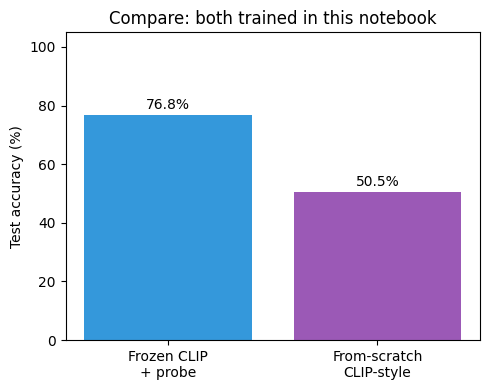

Saved results/scratch_clip_style/scratch_vs_clip_probe.png


In [20]:
model.eval()
test_correct, test_n = 0, 0
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        logits = model(x)
        pred = logits.argmax(1).cpu()
        test_correct += (pred == y).sum().item()
        test_n += x.size(0)

scratch_acc = 100 * test_correct / test_n if test_n else 0

print("=" * 60)
print("Frozen CLIP + probe (this notebook):")
print(f"  Test accuracy: {clip_probe_test_acc:.1f}%")
print()
print("From-scratch CLIP-style model (this notebook):")
print(f"  Test accuracy: {scratch_acc:.1f}%")
print("=" * 60)

fig, ax = plt.subplots(figsize=(5, 4))
labels = ["Frozen CLIP\n+ probe", "From-scratch\nCLIP-style"]
values = [clip_probe_test_acc, scratch_acc]
colors = ["#3498db", "#9b59b6"]
bars = ax.bar([0, 1], values, color=colors)
ax.bar_label(bars, [f"{clip_probe_test_acc:.1f}%", f"{scratch_acc:.1f}%"], padding=2)
ax.set_xticks([0, 1])
ax.set_xticklabels(labels)
ax.set_ylabel("Test accuracy (%)")
ax.set_ylim(0, 105)
ax.set_title("Compare: both trained in this notebook")
plt.tight_layout()
plt.show()
Path(CONFIG["results_dir"]).mkdir(parents=True, exist_ok=True)
fig.savefig(Path(CONFIG["results_dir"]) / "scratch_vs_clip_probe.png", dpi=150, bbox_inches="tight")
print(f"Saved {CONFIG['results_dir']}/scratch_vs_clip_probe.png")